In [ ]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import re
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
dataset = pd.read_csv(
    'Restaurant_Reviews.tsv',
    delimiter='\t',
    quoting=3
)

dataset.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [ ]:
# Shape of the dataset

dataset.shape

(1000, 2)

In [ ]:
# Display first 10 rows

dataset.head(10)

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1
5,Now I am getting angry and I want my damn pho.,0
6,Honeslty it didn't taste THAT fresh.),0
7,The potatoes were like rubber and you could te...,0
8,The fries were great too.,1
9,A great touch.,1


In [ ]:
# Display last 10 rows

dataset.tail(10)

,Review,Liked
990,The refried beans that came with my meal were ...,0
991,Spend your money and time some place else.,0
992,A lady at the table next to us found a live gr...,0
993,the presentation of the food was awful.,0
994,I can't tell you how disappointed I was.,0
995,I think food should have flavor and texture an...,0
996,Appetite instantly gone.,0
997,Overall I was not impressed and would not go b...,0
998,"The whole experience was underwhelming, and I ...",0
999,"Then, as if I hadn't wasted enough of my life ...",0


In [ ]:
# Dataset information

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  1000 non-null   object
 1   Liked   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


In [ ]:
# Statistical summary

dataset.describe(include='all')

,Review,Liked
count,1000,1000.00000
unique,996,NaN
top,I would not recommend this place.,NaN
freq,2,NaN
mean,NaN,0.50000
std,NaN,0.50025
min,NaN,0.00000
25%,NaN,0.00000
50%,NaN,0.50000
75%,NaN,1.00000


In [ ]:
# Check missing values

dataset.isnull().sum()

,0
Review,0
Liked,0


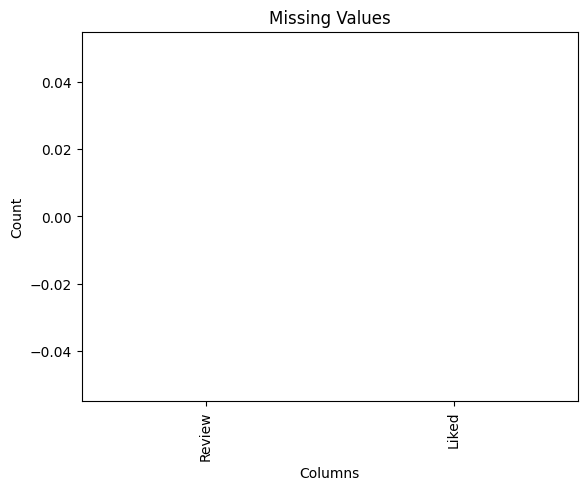

In [ ]:
# Visualize missing values

import matplotlib.pyplot as plt

dataset.isnull().sum().plot(kind='bar')
plt.title("Missing Values")
plt.xlabel("Columns")
plt.ylabel("Count")
plt.show()

In [ ]:
# Count duplicate rows

dataset.duplicated().sum()

np.int64(4)

In [ ]:
# Remove duplicate rows

dataset = dataset.drop_duplicates()

dataset.shape

(996, 2)

In [ ]:
# Count positive and negative reviews

dataset['Liked'].value_counts()

,count
Liked,
1,499
0,497


In [ ]:
# Percentage of each class

dataset['Liked'].value_counts(normalize=True) * 100

,proportion
Liked,
1,50.100402
0,49.899598


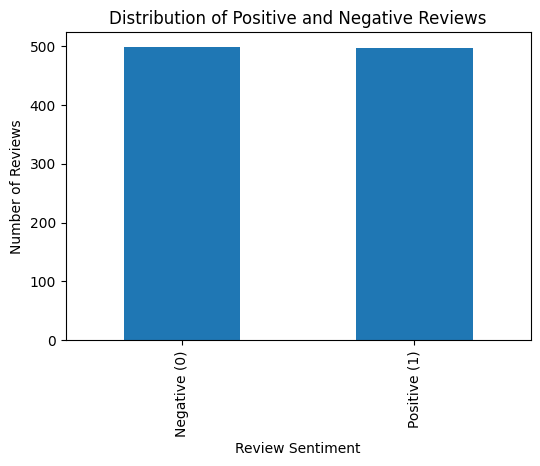

In [ ]:
# Bar chart of review sentiments

dataset['Liked'].value_counts().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Distribution of Positive and Negative Reviews")
plt.xlabel("Review Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks([0,1], ["Negative (0)", "Positive (1)"])
plt.show()

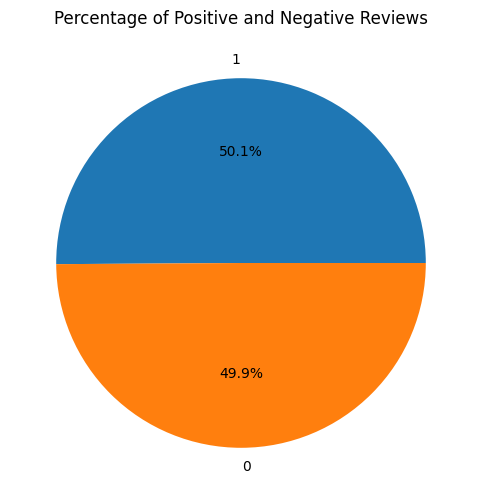

In [ ]:
# Pie chart of review sentiments

dataset['Liked'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Percentage of Positive and Negative Reviews")
plt.ylabel("")
plt.show()

In [ ]:
# Calculate review length

dataset['Review_Length'] = dataset['Review'].apply(len)

dataset.head()

,Review,Liked,Review_Length
0,Wow... Loved this place.,1,24
1,Crust is not good.,0,18
2,Not tasty and the texture was just nasty.,0,41
3,Stopped by during the late May bank holiday of...,1,87
4,The selection on the menu was great and so wer...,1,59


In [ ]:
# Summary statistics of review length

dataset['Review_Length'].describe()

,Review_Length
count,996.000000
mean,58.459839
std,32.341292
min,11.000000
25%,33.000000
50%,51.000000
75%,80.000000
max,149.000000


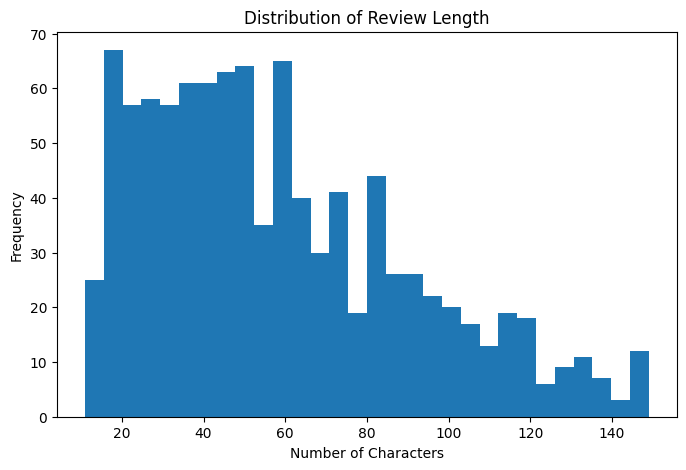

In [ ]:
# Histogram of review lengths

plt.figure(figsize=(8,5))

plt.hist(dataset['Review_Length'], bins=30)

plt.title("Distribution of Review Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

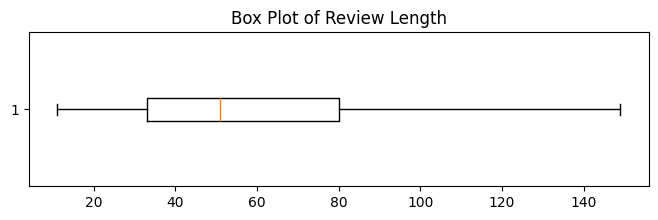

In [ ]:
# Box plot of review length

plt.figure(figsize=(8,2))

plt.boxplot(dataset['Review_Length'], vert=False)

plt.title("Box Plot of Review Length")

plt.show()

In [ ]:
# Longest review

print("Longest Review:")
print(dataset.loc[dataset['Review_Length'].idxmax(), 'Review'])

print("\nLength:", dataset['Review_Length'].max())

print("\n" + "="*80 + "\n")

# Shortest review

print("Shortest Review:")
print(dataset.loc[dataset['Review_Length'].idxmin(), 'Review'])

print("\nLength:", dataset['Review_Length'].min())

Longest Review:
The problem I have is that they charge $11.99 for a sandwich that is no bigger than a Subway sub (which offers better and more amount of vegetables).

Length: 149


Shortest Review:
DELICIOUS!!

Length: 11


In [ ]:
# Import libraries for word frequency analysis

from collections import Counter

In [ ]:
# Combine all reviews into one string

all_words = ' '.join(dataset['Review'])

# Convert into lowercase words

words = all_words.lower().split()

# Count frequency

word_count = Counter(words)

# Display 20 most common words

word_count.most_common(20)

[('the', 581),
 ('and', 388),
 ('i', 300),
 ('was', 291),
 ('a', 237),
 ('to', 216),
 ('is', 171),
 ('this', 140),
 ('of', 125),
 ('not', 114),
 ('it', 110),
 ('for', 107),
 ('in', 104),
 ('food', 91),
 ('we', 79),
 ('place', 77),
 ('very', 74),
 ('my', 72),
 ('with', 72),
 ('so', 66)]

In [ ]:
# Convert to DataFrame

top_words = pd.DataFrame(
    word_count.most_common(20),
    columns=['Word', 'Frequency']
)

top_words

,Word,Frequency
0,the,581
1,and,388
2,i,300
3,was,291
4,a,237
5,to,216
6,is,171
7,this,140
8,of,125
9,not,114


In [ ]:
corpus = []
ps = PorterStemmer()

for i in range(0, len(dataset)):
    review = re.sub('[^a-zA-Z]', ' ', dataset['Review'].iloc[i])
    review = review.lower()
    review = review.split()

    review = [ps.stem(word) for word in review
              if word not in set(stopwords.words('english'))]

    review = ' '.join(review)
    corpus.append(review)

In [ ]:
corpus[:5]

['wow love place',
 'crust good',
 'tasti textur nasti',
 'stop late may bank holiday rick steve recommend love',
 'select menu great price']

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=1500)

X = cv.fit_transform(corpus).toarray()

y = dataset['Liked'].values

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=0
)

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

GaussianNB()

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=0)

lr.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=0)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=0)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='linear', random_state=0)

svm.fit(X_train, y_train)

SVC(kernel='linear', random_state=0)

In [ ]:
from sklearn.metrics import accuracy_score

models = {
    "Naive Bayes": nb,
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "SVM": svm
}

for name, model in models.items():
    pred = model.predict(X_test)
    print(name, ":", round(accuracy_score(y_test, pred)*100,2), "%")

Naive Bayes : 70.0 %
Logistic Regression : 74.0 %
Decision Tree : 69.0 %
Random Forest : 70.0 %
SVM : 74.5 %


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, svm.predict(X_test)))

              precision    recall  f1-score   support

           0       0.69      0.81      0.75        93
           1       0.80      0.69      0.74       107

    accuracy                           0.74       200
   macro avg       0.75      0.75      0.74       200
weighted avg       0.75      0.74      0.74       200



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, svm.predict(X_test))

print(cm)

[[75 18]
 [33 74]]


In [ ]:
review = "The food was delicious and the service was excellent."

review = re.sub('[^a-zA-Z]', ' ', review)
review = review.lower()
review = review.split()

review = [ps.stem(word) for word in review if word not in set(stopwords.words('english'))]

review = ' '.join(review)

review = cv.transform([review]).toarray()

prediction = svm.predict(review)

if prediction[0] == 1:
    print("Positive Review 😊")
else:
    print("Negative Review 😞")

Positive Review 😊


In [ ]:
import pickle

pickle.dump(svm, open("restaurant_model.pkl", "wb"))
pickle.dump(cv, open("cv.pkl", "wb"))

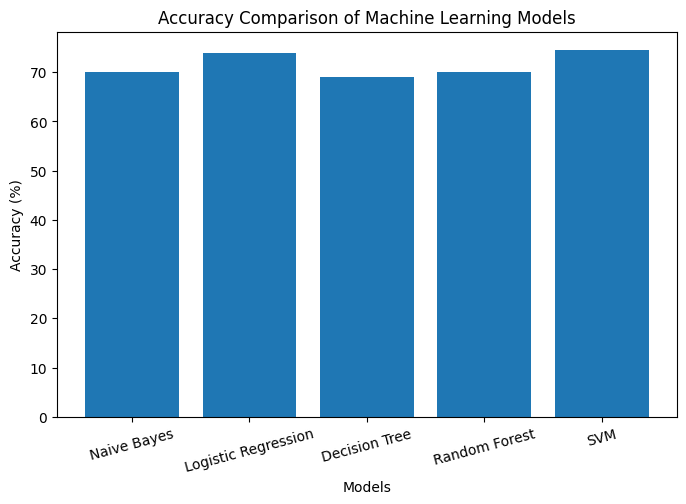

In [ ]:
import matplotlib.pyplot as plt

model_names = ["Naive Bayes", "Logistic Regression", "Decision Tree", "Random Forest", "SVM"]
accuracies = []

for model in [nb, lr, dt, rf, svm]:
    pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, pred) * 100)

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies)
plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=15)
plt.show()

In [ ]:
accuracy_df = pd.DataFrame({
    "Model": model_names,
    "Accuracy (%)": accuracies
})

accuracy_df.sort_values(by="Accuracy (%)", ascending=False)

,Model,Accuracy (%)
4,SVM,74.5
1,Logistic Regression,74.0
0,Naive Bayes,70.0
3,Random Forest,70.0
2,Decision Tree,69.0


In [ ]:
!pip install wordcloud

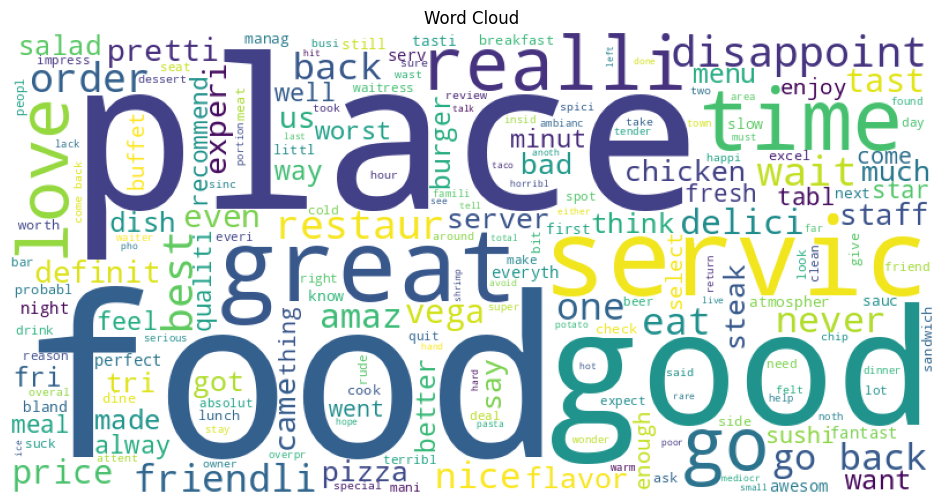

In [ ]:
from wordcloud import WordCloud

text = " ".join(corpus)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

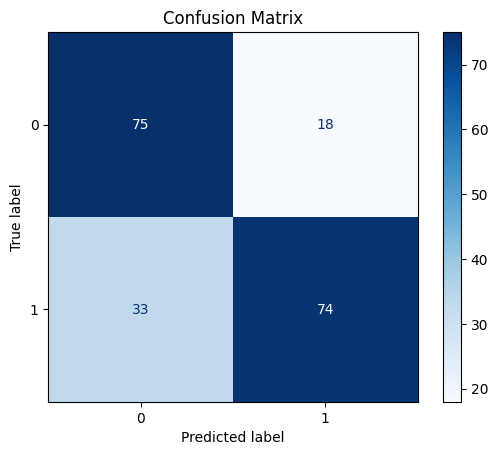

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    svm,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()